In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout

In [6]:
df=pd.read_csv('GOOG.csv')
df.head()

,symbol,date,close,high,low,open,volume,adjClose,adjHigh,adjLow,adjOpen,adjVolume,divCash,splitFactor
0,GOOG,2016-06-14 00:00:00+00:00,718.27,722.47,713.1200,716.48,1306065,718.27,722.47,713.1200,716.48,1306065,0.0,1.0
1,GOOG,2016-06-15 00:00:00+00:00,718.92,722.98,717.3100,719.00,1214517,718.92,722.98,717.3100,719.00,1214517,0.0,1.0
2,GOOG,2016-06-16 00:00:00+00:00,710.36,716.65,703.2600,714.91,1982471,710.36,716.65,703.2600,714.91,1982471,0.0,1.0
3,GOOG,2016-06-17 00:00:00+00:00,691.72,708.82,688.4515,708.65,3402357,691.72,708.82,688.4515,708.65,3402357,0.0,1.0
4,GOOG,2016-06-20 00:00:00+00:00,693.71,702.48,693.4100,698.77,2082538,693.71,702.48,693.4100,698.77,2082538,0.0,1.0


In [10]:
df.isnull().sum()


symbol         0
date           0
close          0
high           0
low            0
open           0
volume         0
adjClose       0
adjHigh        0
adjLow         0
adjOpen        0
adjVolume      0
divCash        0
splitFactor    0
dtype: int64

In [11]:
x=df["open"].values.reshape(-1,1)
x

array([[ 716.48],
       [ 719.  ],
       [ 714.91],
       ...,
       [2499.5 ],
       [2494.01],
       [2524.92]], shape=(1258, 1))

In [13]:
scaler=MinMaxScaler(feature_range=(0,1))
x_scaled=scaler.fit_transform(x)

In [16]:
x_train=[]
y_train=[]
for i in range(60,len(x_scaled)):
    x_train.append(x_scaled[i-60:i,0])
    y_train.append(x_scaled[i,0])
x_train,y_train=np.array(x_train),np.array(y_train)
x_train=np.reshape(x_train,(x_train.shape[0],x_train.shape[1],1))

model=Sequential()
model.add(LSMT(units=50, return_sequences=True, input_shape=(x_train.shape[1],1)))
model.add(Dropout(0.2))
model.add(LSMT(units=50, return_sequences=True))
model.add(Dropout(0.2))
model.add(LSMT(units=50))
model.add(Dropout(0.2))
model.add(Dense(units=))

In [19]:
model=Sequential() 
model.add(LSTM(units=50, return_sequences=True, input_shape=(x_train.shape[1],1))) 
model.add(Dropout(0.2))
model.add(LSTM(units=50, return_sequences=True)) 
model.add(Dropout(0.2)) 
model.add(LSTM(units=50)) 
model.add(Dropout(0.2))
model.add(Dense(units=1))

C:\Users\SONIYA\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [21]:
model.compile(optimizer='adam',loss="mean_squared_error")
model.fit(x_train,y_train,epochs=50,batch_size=32)

Epoch 1/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 7s 53ms/step - loss: 0.0125
Epoch 2/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - loss: 0.0023
Epoch 3/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - loss: 0.0023
Epoch 4/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - loss: 0.0022
Epoch 5/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - loss: 0.0021
Epoch 6/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - loss: 0.0019
Epoch 7/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - loss: 0.0020
Epoch 8/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - loss: 0.0022
Epoch 9/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - loss: 0.0022
Epoch 10/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - loss: 0.0020
Epoch 11/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - loss: 0.0019
Epoch 12/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - loss: 0.0019
Epoch 13/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - loss: 0.0016
Epoch 14/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - loss: 0.0017
Epoch 15/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - loss: 0.0015
Epoc

In [22]:
predicted_stock=model.predict(x_train)
predicted_stock=scaler.inverse_transform(predicted_stock)

38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step


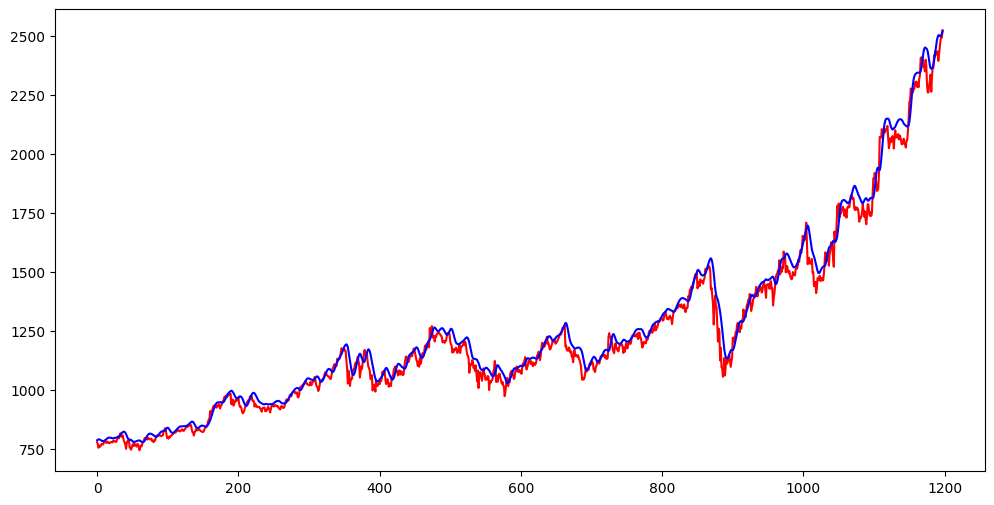

In [23]:
plt.figure(figsize=(12,6))
plt.plot(x[60:],color="red")
plt.plot(predicted_stock,color="blue")
plt.show()